In [ ]:
!pip install preliz
!pip install bambi

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

The benefit for multiple polynomial element in a mmodel is that they make  easier for MCMC to run, and easier to interpret our intercepts, because the orthongality of the terms means they are more independent. Addtionaly, it's easier to write it ( in the case of the polynomial)-> so that's a benefit to use a polynomial in a model.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?
As the higher the degree of a polynomial thde worse the model gets in some cases.

**Task3**:

What's the point of using b splines?
B splines are a good way to get the flexibility of a ploynomial regression- with less overfitting.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.
I think the gaussian process like  a way to define a distribution in a plot.

\

```
# This is formatted as code
```

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [11]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
model_poly_7_t = bmb.Model("weight ~ poly(height, degree=7)", howell, family="negativebinomial")
idata_poly_7_t = model_poly_7_t.fit()

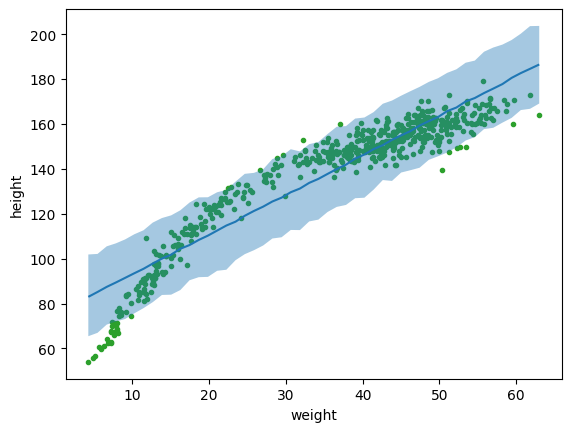

In [14]:
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [ ]:
num_knots = 6
min_height = howell["height"].min()##Used gemini
max_height = howell["height"].max()##Used gemini
knots = np.linspace(min_height, max_height, num_knots + 2)[1:-1]##Used gemini
model_spline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline = model_spline.fit()

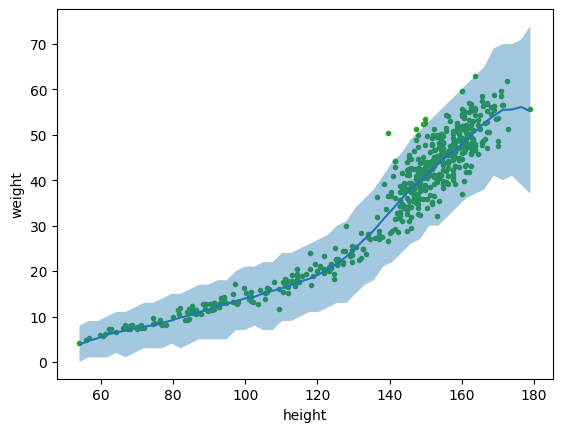

In [20]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [22]:
#convert from pandas to numpy array
r = howell["weight"].values
h = howell["height"].values[:,None]

In [23]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
with pm.Model() as model_hsgp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(h))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    #f is for function, as in the function we use to transform our data
    f = gp.prior('f', X=h)
    #prior for the neg binomial
    α = pm.HalfNormal('α', 1)
    #likelihood
    y = pm.NegativeBinomial("y", np.exp(f), α, observed=r)

    idata_hsgp = pm.sample()

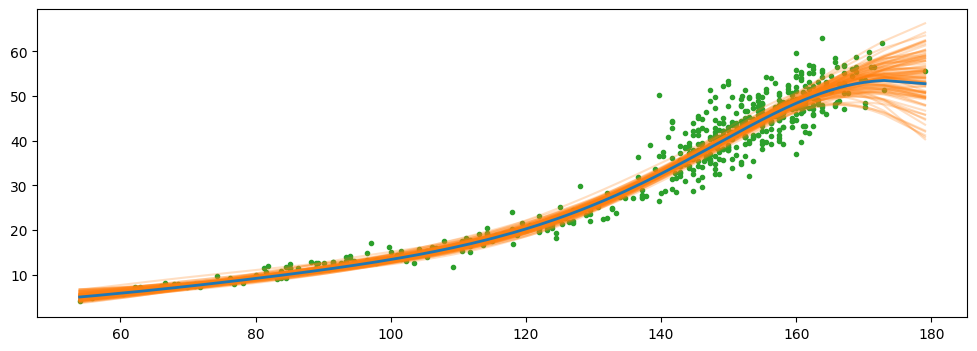

In [25]:
#set up plot
_, ax = plt.subplots(1, 1, figsize=(12, 4))
#plot raw data
ax.plot(howell["height"].values, howell["weight"].values, "C2.")

#grab posterior
f = az.extract(idata_hsgp, group="posterior", var_names="f")


idx = np.argsort(howell["height"].values)
#plot samples of the posterior
ax.plot(howell["height"].values[idx], np.exp(f.values[idx,:100]), alpha=0.25, color="C1")
#plot posterior mean
ax.plot(howell["height"].values[idx], np.exp(f.values[idx].mean(1)), color="C0", lw=2)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.



GP handles unorgainsed data with no problem- you not neccarly need to clean data.



**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.
I think my favorite grpah in the article was  the first grpah as I liked how it was to an extend a little bit had a positive cooralation as well as having the year and the amount of ice present specific to a cause and a clear sharp positive cooralation.
